In [ ]:
# GPU 사용 설정
import tensorflow as tf
print("GPU 사용 가능:", tf.config.list_physical_devices('GPU'))

GPU 사용 가능: []


In [ ]:
# 필요한 라이브러리
import tensorflow_datasets as tfds  # 데이터셋 다운로드용
import numpy as np  # 수치 계산용
import matplotlib.pyplot as plt  # 그래프 그리기용
from tensorflow.keras.models import Sequential  # 모델 구조용
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # 신경망 층들
from tensorflow.keras.optimizers import Adam  # 모델 최적화 알고리즘
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # 훈련 제어용

In [ ]:
# 데이터셋 로드
(ds_train, ds_test), ds_info = tfds.load(
    'rock_paper_scissors',  # 가위바위보 데이터셋
    split=['train', 'test'],  # 훈련용, 테스트용으로 분할
    with_info=True,  # 데이터 정보도 함께 받기
    as_supervised=True  # 이미지와 정답 라벨을 함께 받기
)

print(f"훈련 데이터: {ds_info.splits['train'].num_examples}개")
print(f"테스트 데이터: {ds_info.splits['test'].num_examples}개")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.T7ZFUO_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.T7ZFUO_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.
훈련 데이터: 2520개
테스트 데이터: 372개


In [ ]:
# 데이터 전처리 함수
def preprocess_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # 정규화: 0~255 값을 0~1로 변환
    image = tf.image.resize(image, [150, 150])  # 크기 통일: 150x150 픽셀로 조정
    return image, label

In [ ]:
# 데이터 증강 (Data Augmentation)
def augment_image(image, label):
    image = tf.image.random_flip_left_right(image)  # 좌우 반전
    image = tf.image.random_brightness(image, 0.2)  # 밝기 조정
    image = tf.image.random_contrast(image, 0.8, 1.2)  # 대비 조정
    return image, label

In [ ]:
# 데이터 전처리 및 배치 설정
BATCH_SIZE = 32  # 한 번에 처리할 이미지 개수
BUFFER_SIZE = 1000  # 셔플링할 때 사용할 버퍼 크기

In [ ]:
# 훈련 데이터 전처리 (데이터 증강 포함)
train_dataset = ds_train.map(preprocess_image).map(augment_image)
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
# 테스트 데이터 전처리
test_dataset = ds_test.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
# CNN 모델 구성
model = Sequential([
    # 첫 번째 컨볼루션 블록
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),  # 32개 필터, 3x3 크기
    MaxPooling2D(2, 2),  # 2x2 영역을 하나로 줄임

    # 두 번째 컨볼루션 블록
    Conv2D(64, (3, 3), activation='relu'),  # 64개 필터
    MaxPooling2D(2, 2),

    # 세 번째 컨볼루션 블록
    Conv2D(128, (3, 3), activation='relu'),  # 128개 필터
    MaxPooling2D(2, 2),

    # 네 번째 컨볼루션 블록
    Conv2D(128, (3, 3), activation='relu'),  # 128개 필터
    MaxPooling2D(2, 2),

    # 분류를 위한 완전연결층
    Flatten(),  # 2D 이미지를 1D로 평평하게 만듦
    Dropout(0.5),  # 과적합 방지: 50% 뉴런을 무작위로 끔
    Dense(512, activation='relu'),  # 512개 뉴런의 완전연결층
    Dense(3, activation='softmax')  # 3개 클래스 (가위, 바위, 보) 출력
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 모델 컴파일
model.compile(
    optimizer=Adam(learning_rate=0.001),  # 최적화 알고리즘과 학습률
    loss='sparse_categorical_crossentropy',  # 손실 함수
    metrics=['accuracy']  # 평가 지표
)

In [ ]:
# 모델 구조 확인
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,454,147 (13.18 MB)

 Trainable params: 3,454,147 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 콜백 설정
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),  # 조기 종료
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)  # 최고 성능 모델 저장
]

In [ ]:
# 모델 훈련
EPOCHS = 20  # 최대 20번 반복 학습

history = model.fit(
    train_dataset,  # 훈련 데이터
    epochs=EPOCHS,  # 반복 횟수
    validation_data=test_dataset,  # 검증 데이터
    callbacks=callbacks,  # 훈련 제어
    verbose=1  # 훈련 과정 출력
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5828 - loss: 0.7911

79/79 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.5854 - loss: 0.7867 - val_accuracy: 0.8118 - val_loss: 0.7300
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.9867 - loss: 0.0501 - val_accuracy: 0.7419 - val_loss: 0.8838
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9932 - loss: 0.0255

79/79 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.9932 - loss: 0.0255 - val_accuracy: 0.8441 - val_loss: 1.1424
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9904 - loss: 0.0288

79/79 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9905 - loss: 0.0288 - val_accuracy: 0.8522 - val_loss: 0.6420
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9981 - loss: 0.0057 - val_accuracy: 0.8468 - val_loss: 0.8448
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.8360 - val_loss: 1.0904
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.9981 - loss: 0.0032 - val_accuracy: 0.7957 - val_loss: 1.7917
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9948 - loss: 0.0109

79/79 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.9949 - loss: 0.0108 - val_accuracy: 0.8629 - val_loss: 0.5843
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9911 - loss: 0.0169 - val_accuracy: 0.8548 - val_loss: 0.9845
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9947 - loss: 0.0166 - val_accuracy: 0.8629 - val_loss: 1.0816
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9983 - loss: 0.0063

79/79 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.9983 - loss: 0.0064 - val_accuracy: 0.8683 - val_loss: 0.9002
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9968 - loss: 0.0106 - val_accuracy: 0.7930 - val_loss: 1.4931
Epoch 13/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.9985 - loss: 0.0093 - val_accuracy: 0.8226 - val_loss: 1.2664
Epoch 14/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9946 - loss: 0.0110

79/79 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9946 - loss: 0.0109 - val_accuracy: 0.8763 - val_loss: 1.3345
Epoch 15/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.9993 - loss: 0.0026 - val_accuracy: 0.7715 - val_loss: 1.4603
Epoch 16/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9950 - loss: 0.0209

79/79 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9950 - loss: 0.0209 - val_accuracy: 0.8844 - val_loss: 1.3680
Epoch 17/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9971 - loss: 0.0189

79/79 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9971 - loss: 0.0188 - val_accuracy: 0.9220 - val_loss: 0.4016
Epoch 18/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9980 - loss: 0.0024

79/79 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9981 - loss: 0.0024 - val_accuracy: 0.9355 - val_loss: 0.3112
Epoch 19/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 1.0000 - loss: 1.1983e-04 - val_accuracy: 0.9247 - val_loss: 0.3317
Epoch 20/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 1.0000 - loss: 1.7843e-04 - val_accuracy: 0.9059 - val_loss: 0.4608


In [ ]:
# 훈련 결과 시각화
plt.figure(figsize=(12, 4))

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

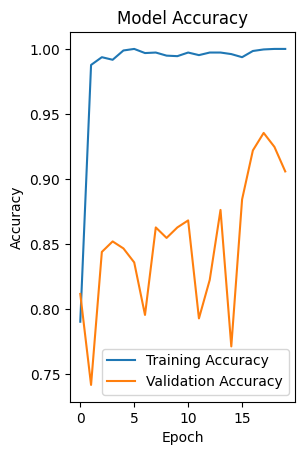

In [ ]:
# 정확도 그래프
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

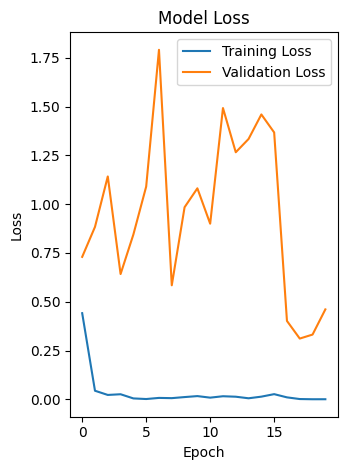

In [ ]:
# 손실 그래프
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 최종 평가
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=0)
print(f"\n최종 테스트 정확도: {test_accuracy:.4f}")
print(f"최종 테스트 손실: {test_loss:.4f}")


최종 테스트 정확도: 0.9355
최종 테스트 손실: 0.3112


In [ ]:
# 예측 함수
def predict_and_show(model, dataset, num_samples=9):
    class_names = ['rock', 'paper', 'scissors']

    plt.figure(figsize=(12, 12))

    # 샘플 이미지 가져오기
    images, labels = next(iter(dataset.take(1)))
    predictions = model.predict(images)

    for i in range(min(num_samples, len(images))):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i])

        predicted_class = np.argmax(predictions[i])
        true_class = labels[i].numpy()

        plt.title(f'real : {class_names[true_class]}\n'
                 f'prediction : {class_names[predicted_class]}\n'
                 f'confidence : {np.max(predictions[i]):.2f}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step


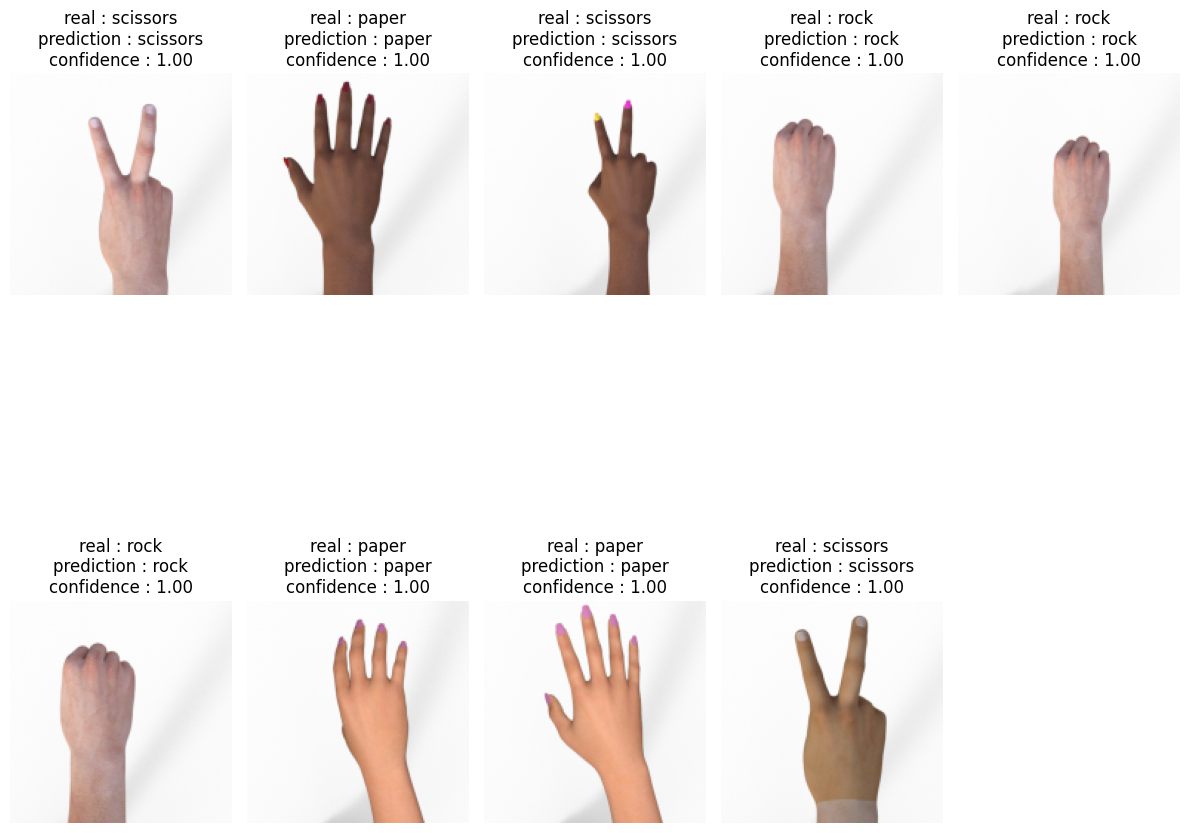

In [ ]:
# 예측 결과 확인
predict_and_show(model, test_dataset)